# TP1: Sistema de Reconocimiento Facial - Desarrollo y Experimentación

Este notebook contiene el pipeline completo para el desarrollo del sistema de reconocimiento facial, desde la preparación del entorno hasta la evaluación de métricas.

---

## Equipo
- Alumno 1: Tapia Fabrizio
- Alumno 2: Caterina Martinez Dufour

## 1. Instalación de Dependencias
En esta sección se configuran las librerías necesarias para el procesamiento de imágenes y la ejecución de modelos de Deep Learning.
*   **Insightface:** Framework avanzado para análisis facial.
*   **OpenCV:** Manipulación de imágenes y video.
*   **ONNX Runtime (GPU):** Motor de inferencia optimizado.

In [1]:
!pip install insightface opencv-python onnxruntime-gpu
!pip install kagglehub

  Using cached insightface-0.7.3.tar.gz (439 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached onnxruntime_gpu-1.25.1-cp312-cp312-win_amd64.whl.metadata (5.8 kB)
INFO: pip is looking at multiple versions of matplotlib to determine which version is compatible with other requirements. This could take a while.
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
Using cached onnxruntime_gpu-1.25.1-cp312-cp312-win_amd64.whl (221.7 MB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Failed to build insightface


  error: subprocess-exited-with-error
  
  × Building wheel for insightface (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [213 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-312\insightface
      copying insightface\__init__.py -> build\lib.win-amd64-cpython-312\insightface
      creating build\lib.win-amd64-cpython-312\insightface\app
      copying insightface\app\common.py -> build\lib.win-amd64-cpython-312\insightface\app
      copying insightface\app\face_analysis.py -> build\lib.win-amd64-cpython-312\insightface\app
      copying insightface\app\mask_renderer.py -> build\lib.win-amd64-cpython-312\insightface\app
      copying insightface\app\__init__.py -> build\lib.win-amd64-cpython-312\insightface\app
      creating build\lib.win-amd64-cpython-312\insightface\commands
      copying insightface\commands\insightface_cli.py -> build\lib.win-amd64-cpython-312\insightface\commands
  


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Carga del Dataset
Conexión con el almacenamiento (Google Drive o Local) y exploración inicial de las imágenes de entrenamiento y prueba. Se busca asegurar que las etiquetas y rutas sean consistentes.

In [26]:
import kagglehub
import shutil
from pathlib import Path

data_path = Path("data")
data_path.mkdir(parents=True, exist_ok=True)

downloaded_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

dest_path = data_path / "lfw-dataset"

if not dest_path.exists():
    print(f"Copiando dataset a {dest_path}...")
    shutil.copytree(downloaded_path, dest_path)

path = str(dest_path.absolute())
print("Path to dataset files:", path)

Path to dataset files: c:\Users\Usuario\tuia-face-recognition-app\data\lfw-dataset


### Vista previa del Dataset
Visualizamos algunas imágenes aleatorias para confirmar que la carga fue exitosa y verificar que los nombres de las carpetas correspondan a las identidades.

Total de imágenes encontradas: 13233


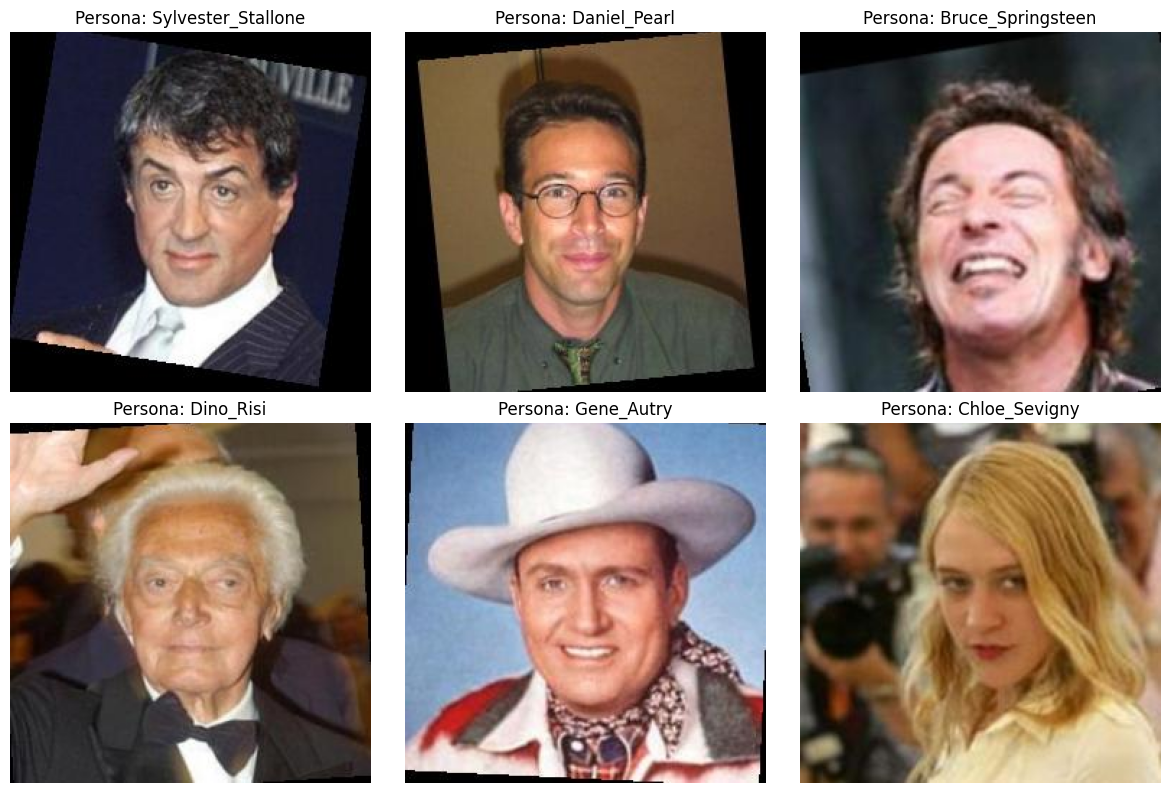

In [27]:
import matplotlib.pyplot as plt
from pathlib import Path
import random
from PIL import Image

base_path = Path(path)
all_images = list(base_path.glob('**/*.jpg'))

print(f"Total de imágenes encontradas: {len(all_images)}")

if all_images:
    sample_images = random.sample(all_images, min(6, len(all_images)))
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sample_images):
        plt.subplot(2, 3, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Persona: {img_path.parent.name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Análisis Estadístico del Dataset
Para un sistema de reconocimiento facial, el balance del dataset es crítico. Analizaremos cuántas imágenes tenemos por persona y quiénes son las identidades más frecuentes. Esto nos ayudará a decidir qué umbrales utilizar y cómo seleccionar nuestro conjunto de prueba.

Análisis de Identidades:
- Total de personas únicas: 5749
- Promedio de fotos por persona: 2.30
- Persona con más fotos: George_W_Bush (530 fotos)
- Personas con una sola foto: 4069


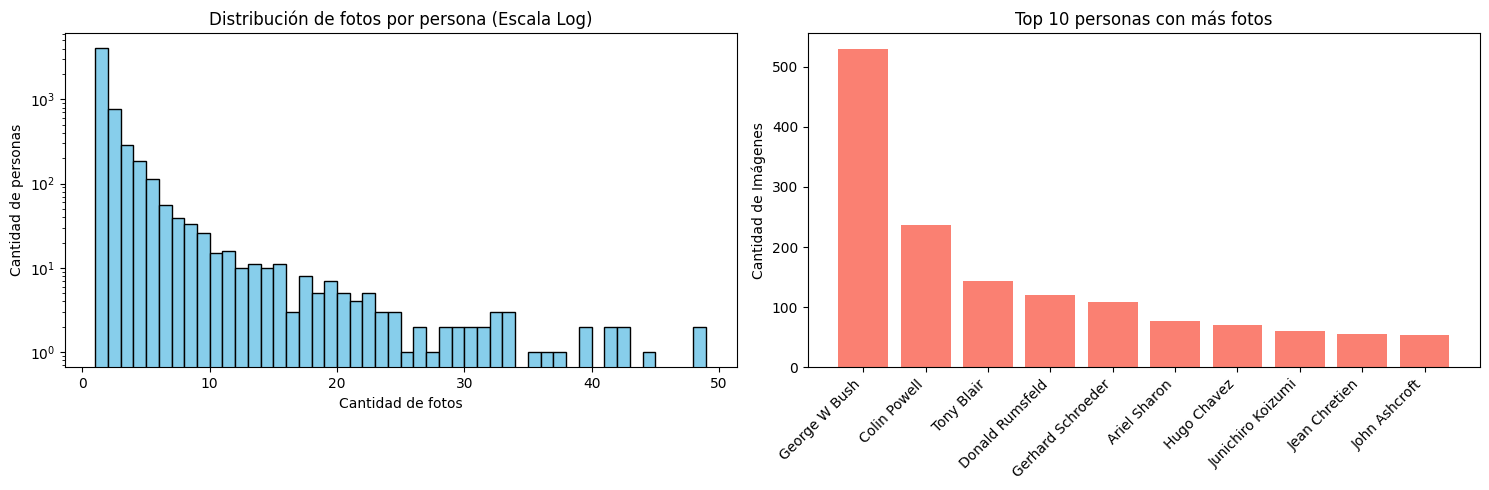

In [6]:
from collections import Counter

# Contar imágenes por persona (basado en el nombre de la carpeta padre)
identities = [p.parent.name for p in all_images]
counts = Counter(identities)

num_identities = len(counts)
img_per_person = list(counts.values())

print(f"Análisis de Identidades:")
print(f"- Total de personas únicas: {num_identities}")
print(f"- Promedio de fotos por persona: {len(all_images) / num_identities:.2f}")
print(f"- Persona con más fotos: {counts.most_common(1)[0][0]} ({counts.most_common(1)[0][1]} fotos)")
print(f"- Personas con una sola foto: {sum(1 for c in img_per_person if c == 1)}")

# Visualizar distribución y Top 10
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(img_per_person, bins=range(1, 50), color='skyblue', edgecolor='black')
plt.yscale('log') # Escala logarítmica para ver la diferencia entre los extremos
plt.title("Distribución de fotos por persona (Escala Log)")
plt.xlabel("Cantidad de fotos")
plt.ylabel("Cantidad de personas")

plt.subplot(1, 2, 2)
top_10 = counts.most_common(10)
plt.bar([x[0].replace('_', ' ') for x in top_10], [x[1] for x in top_10], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 personas con más fotos")
plt.ylabel("Cantidad de Imágenes")

plt.tight_layout()
plt.show()

### Segmentación del Dataset
Dividimos el dataset en tres grupos estratégicos:
1.  **Grupo A (Conocidos):** Identidades con $\ge 5$ imágenes. Constituyen nuestra base de datos de rostros conocidos.
2.  **Grupo B (Augmentation):** Identidades con 2 a 4 imágenes. Candidatos para aumentar su representación mediante técnicas sintéticas.
3.  **Grupo C (Desconocidos):** Identidades con una sola imagen. Actúan como el grupo de control para evaluar el rechazo de sujetos no registrados.

--- Análisis de Segmentación ---
Grupo A [Conocidos (>=5)]: 423 personas (7.4%)
Grupo B [Para Augmentation (2-4)]: 1257 personas (21.9%)
Grupo C [Desconocidos (1)]: 4069 personas (70.8%)

Total de registros en DataFrame: 13233


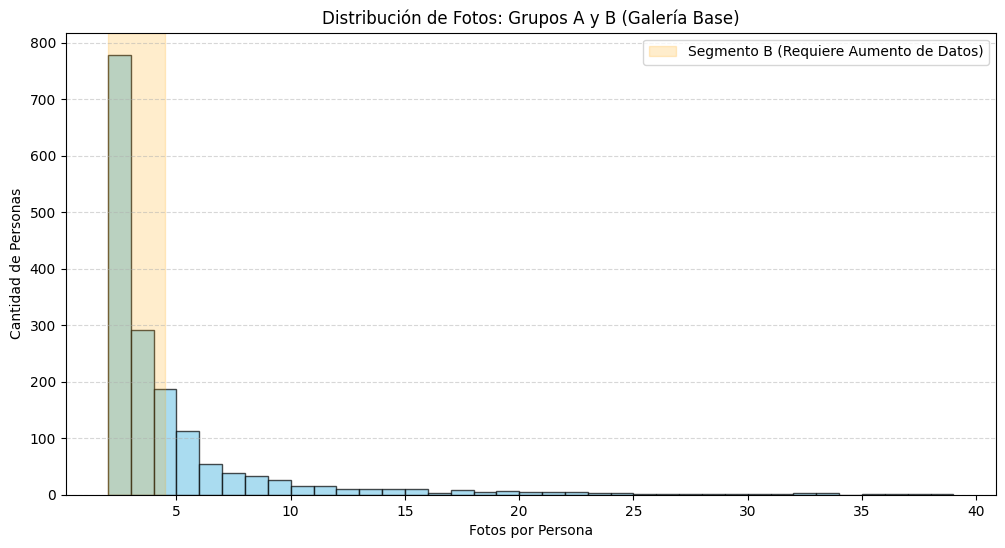

In [7]:
import pandas as pd

# 1. Definir criterios de segmentación
def get_segment(count):
    if count >= 5: return 'A'
    if count >= 2: return 'B'
    return 'C'

id_to_segment = {identity: get_segment(count) for identity, count in counts.items()}

# 2. Análisis Estadístico de los Grupos
total_ids = len(counts)
stats = pd.Series(id_to_segment.values()).value_counts().sort_index()

print("--- Análisis de Segmentación ---")
for seg, count in stats.items():
    label = {"A": "Conocidos (>=5)", "B": "Para Augmentation (2-4)", "C": "Desconocidos (1)"}[seg]
    print(f"Grupo {seg} [{label}]: {count} personas ({count/total_ids:.1%})")

# 3. Preparación del DataFrame de Rutas
df_dataset = pd.DataFrame([
    {'path': str(p), 'label': p.parent.name, 'segmento': id_to_segment[p.parent.name]}
    for p in all_images
])

print(f"\nTotal de registros en DataFrame: {len(df_dataset)}")

# 4. Visualización de Desbalance (Grupos A + B)
plt.figure(figsize=(12, 6))
ab_counts = [count for identity, count in counts.items() if id_to_segment[identity] in ['A', 'B']]

plt.hist(ab_counts, bins=range(2, 40), color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribución de Fotos: Grupos A y B (Galería Base)")
plt.xlabel("Fotos por Persona")
plt.ylabel("Cantidad de Personas")

# Resaltar el Segmento B
plt.axvspan(2, 4.5, color='orange', alpha=0.2, label='Segmento B (Requiere Aumento de Datos)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

df_dataset.to_csv('data/dataset_mapped.csv', index=False)

## 3. Benchmark de Detección: MTCNN vs RetinaFace
Comparativa de algoritmos de detección de rostros.
*   **Objetivo:** Evaluar precisión vs. velocidad y robustez ante variaciones de pose.
*   **Justificación:** Análisis de resultados para la elección del detector que se integrará en el `FaceService`.

Para evaluar la velocidad, precisión y robustez de los detectores MTCNN y RetinaFace, se diseñó un protocolo de pruebas basado en la selección manual de muestras del dataset. Optamos por elegir imágenes manualmente para evaluar el desempeño según cómo el detector toma las fotos en tres situaciones:
- Frontales: Imágenes de frente para ver el rendimiento básico.
- Perfil: Imágenes de costado para ver cómo responden cuando el rostro no está completo.
- Oclusiones: Personas con lentes, manos que tapen el rostro, objetos o accesorios que interfieren con la visión total del rostro.

In [46]:
# listas de imágenes seleccionadas
categorias = {
    "Frontal": ['Duane_Lee_Chapman_0001.jpg', 'Frank_Stallone_0002.jpg', 'Chanda_Rubin_0002.jpg', 'Juan_Francisco_Palencia_0001.jpg', 'Silvio_Berlusconi_0005.jpg'],
    "Perfil": ['Rick_Perry_0003.jpg', 'Olivier_Rochus_0001.jpg', 'Paul_Gannon_0001.jpg', 'Halle_Berry_0008.jpg', 'Alan_Greenspan_0005.jpg'],
    "Oclusiones": ['Ibrahim_Haddad_0001.jpg', 'Jason_Kidd_0009.jpg', 'Bill_Gates_0013.jpg', 'Amelie_Mauresmo_0018.jpg', 'Jack_Straw_0027.jpg']
}

Para evaluar estos detectores aplicamos una función donde se calcula el tiempo de ejecución y la precisión con la que se detectaron las imágenes. También imprimimos los rostros con sus marcas (bounding boxes y puntos clave) para visualizar y comparar los resultados de ambos modelos directamente:

In [43]:
import time
import cv2
import matplotlib.pyplot as plt

def evaluar_detector_generico(detector_app, dicc_categorias, all_paths, tipo="retina"):
    """
    Función para evaluar MTCNN o RetinaFace.
    tipo: "mtcnn" o "retina"
    """
    # Diccionario para buscar el Path completo por nombre de archivo
    path_map = {p.name: p for p in all_paths}
    start_total = time.time()

    for cat_nombre, lista_nombres in dicc_categorias.items():
        print(f"\nEvaluando {tipo.upper()} en: {cat_nombre}")
        plt.figure(figsize=(15, 5))
        detectados = 0
        
        for i, nombre in enumerate(lista_nombres):
            if nombre not in path_map: continue
                
            img_path = path_map[nombre]
            img_bgr = cv2.imread(str(img_path))
            
            # Procesar según el detector
            if tipo == "mtcnn":
                img_input = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                faces = detector_app.detect_faces(img_input)
                img_viz = img_input.copy()
            else: # retina
                faces = detector_app.get(img_bgr)
                img_viz = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            # Dibujar resultados
            if len(faces) > 0:
                detectados += 1
                for face in faces:
                    if tipo == "mtcnn":
                        # Formato MTCNN: [x, y, w, h] y dict de keypoints
                        x, y, w, h = face['box']
                        cv2.rectangle(img_viz, (x, y), (x+w, y+h), (0, 255, 0), 2)
                        for kp in face['keypoints'].values():
                            cv2.circle(img_viz, kp, 2, (255, 0, 0), 2)
                    else:
                        # Formato RetinaFace: .bbox y .kps
                        bbox = face.bbox.astype(int)
                        cv2.rectangle(img_viz, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
                        if face.kps is not None:
                            for kp in face.kps.astype(int):
                                cv2.circle(img_viz, tuple(kp), 2, (255, 0, 0), 2)
            
            plt.subplot(1, len(lista_nombres), i + 1)
            plt.imshow(img_viz)
            plt.title(f"{nombre}", fontsize=8)
            plt.axis('off')
            
        plt.show()
        print(f"Precisión en {cat_nombre}: {(detectados/len(lista_nombres))*100}%")

    end_total = time.time()
    print(f"\nTiempo total de ejecución: {end_total - start_total:.2f} segundos.")

In [ ]:
# Instalamos mtcnn
!pip install mtcnn


Evaluando MTCNN en: Frontal


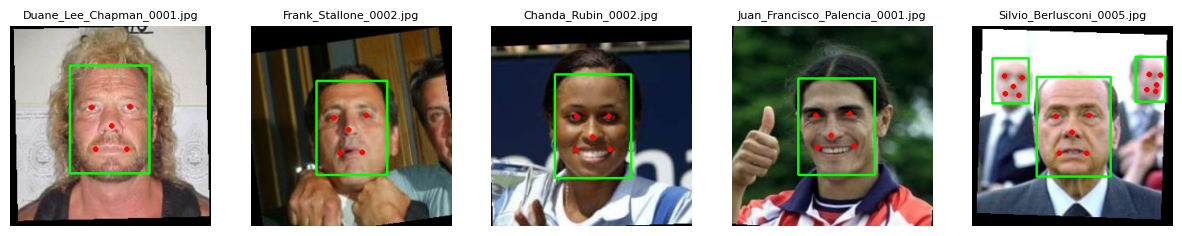

Precisión en Frontal: 100.0%

Evaluando MTCNN en: Perfil


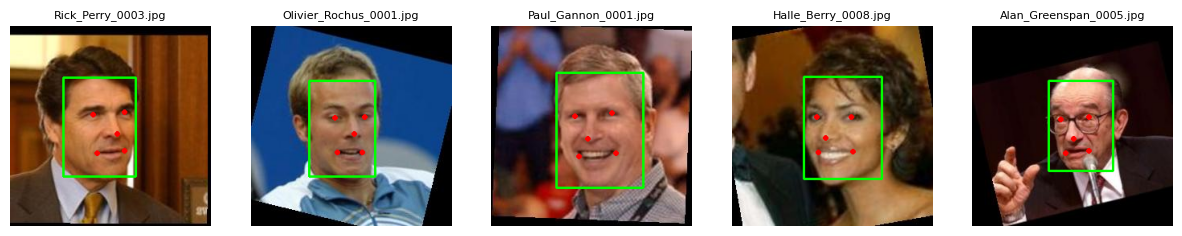

Precisión en Perfil: 100.0%

Evaluando MTCNN en: Oclusiones


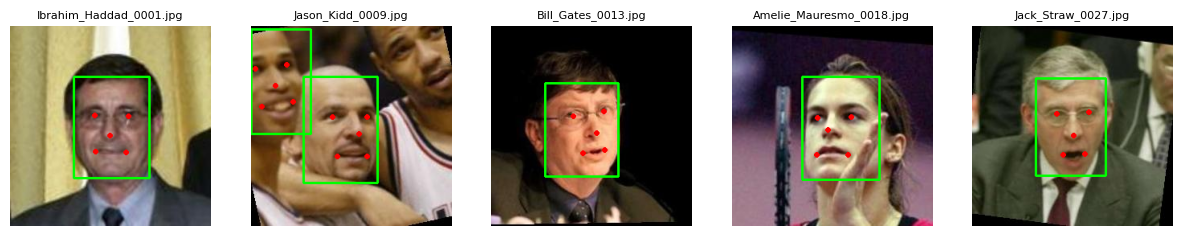

Precisión en Oclusiones: 100.0%

Tiempo total de ejecución: 2.58 segundos.


In [47]:
from mtcnn import MTCNN

# Crea una instancia del detector MTCNN
detector_mtcnn = MTCNN()
evaluar_detector_generico(detector_mtcnn, categorias, all_images, tipo="mtcnn")

In [ ]:
# Instalar insightface
!pip install -U insightface

Debido al tamaño de los modelos de InsightFace, estos no se encuentran en el repositorio. Para ejecutar el notebook, se debe:
- Descargar el archivo buffalo_s.zip desde el repositorio oficial: https://github.com/deepinsight/insightface/releases
- Descomprimir el contenido en la carpeta ./modelos_insight/models/buffalo_s dentro de la raíz del proyecto.

Sin estos archivos, el detector RetinaFace no podrá inicializarse.

In [ ]:
import os

# Definimos la estructura de carpetas necesaria para RetinaFace
ruta_modelos = "./modelos_insight/models/buffalo_s"

if not os.path.exists(ruta_modelos):
    os.makedirs(ruta_modelos)
    print(f"Se creó la carpeta {ruta_modelos}. Por favor, coloque los archivos .onnx de buffalo_s aquí.")
else:
    print("Carpetas de modelos verificadas.")

set det-size: (640, 640)

Evaluando RETINA en: Frontal


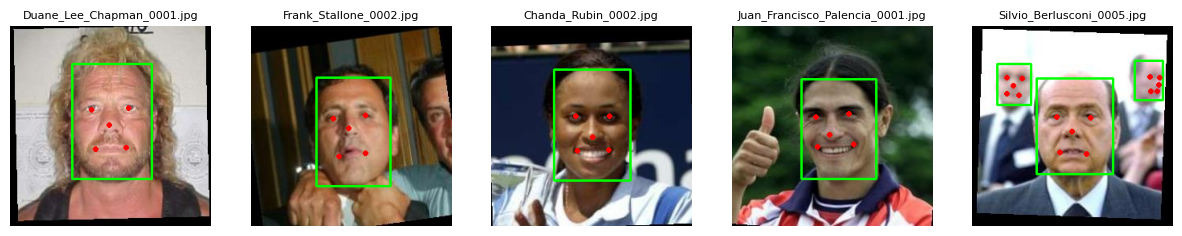

Precisión en Frontal: 100.0%

Evaluando RETINA en: Perfil


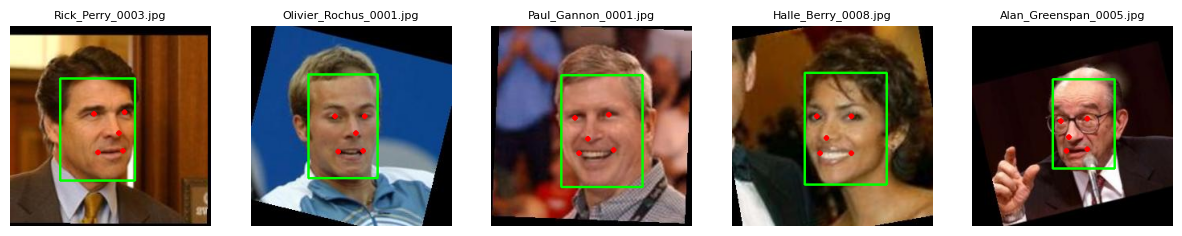

Precisión en Perfil: 100.0%

Evaluando RETINA en: Oclusiones


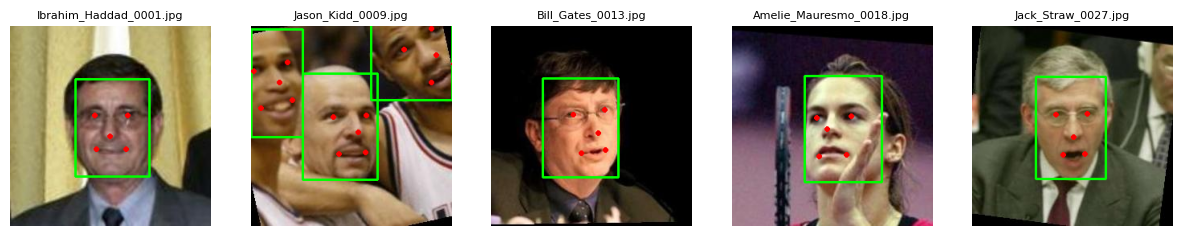

Precisión en Oclusiones: 100.0%

Tiempo total de ejecución: 1.11 segundos.


In [51]:
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model

# 1. PARCHE (Obligatorio para evitar el error de la librería en tu entorno)
def patch_init_final(self, name='buffalo_l', root='~/.insightface', **kwargs):
    self.models = {}
    self.det_model = None
    self.det_thresh = 0.5

# Aplicamos el parche globalmente
FaceAnalysis.__init__ = patch_init_final

# Definimos la ruta al archivo ONNX directamente
path_onnx = "./modelos_insight/models/buffalo_s/det_500m.onnx"

app = FaceAnalysis(name='buffalo_s', root="./modelos_insight")
app.models['detection'] = get_model(path_onnx)
app.det_model = app.models['detection']
app.prepare(ctx_id=-1, det_size=(640, 640))

# Evaluamos el detector con retina
evaluar_detector_generico(app, categorias, all_images, tipo="retina")

Tras analizar ambos detectores, se decidió utilizar RetinaFace porque logró procesar el set de imágenes en 1.13 segundos, reduciendo a menos de la mitad el tiempo requerido por MTCNN (2.55s) y demostró una capacidad superior para detectar rostros que se encuentran parcialmente fuera del encuadre, como se observó en la categoría de oclusiones.

## 4. Generación de Galería (Feature Store)
Implementación de la lógica para transformar imágenes de personas conocidas en vectores representativos (embeddings).
*   Detección y alineación.
*   Extracción de vectores con el modelo elegido.
*   Persistencia en un diccionario o estructura de datos para búsqueda rápida.

In [ ]:
def generate_gallery(path):
    # Recorrer carpetas, detectar rostros y extraer embeddings
    pass

## 5. Pruebas de Inferencia y Pipeline End-to-End
Desarrollo de la función principal de predicción.
1.  **Input:** Imagen sin procesar.
2.  **Pipeline:** Detección -> Alineación -> Extracción -> Identificación (Coseno/L2).
3.  **Output:** Visualización con Bounding Boxes y etiquetas (o "Unknown").

In [ ]:
def predict(image_path):
    # Implementar pipeline completo
    pass

## 6. Cálculo de Métricas y Evaluación
Validación del sistema utilizando un set de testeo.
*   **Matriz de Confusión:** Visualización de aciertos, Falsos Positivos y Falsos Negativos.
*   **Métricas Globales:** Accuracy, Precision y Recall para justificar la fiabilidad del modelo.

In [ ]:
# Generar matriz de confusión y reportar métricas